# Chapter 17: Emerging Threats and Future Challenges

> "The threat landscape does not wait for defenders to catch up." security research community

---

## Learning Objectives

After completing this chapter, you will be able to:

1. Explain the post-quantum cryptography threat and the status of NIST PQC standardisation.
2. Describe AI-enabled attacks and AI-assisted defences.
3. Explain supply chain attacks and their significance.
4. Describe cloud-native security challenges and the shared responsibility model.
5. Explain threats to and from the Internet of Things.
6. Describe zero-day markets and responsible disclosure.
7. Discuss cyber-physical systems risks and the convergence of IT and OT.
8. Evaluate the impact of emerging technologies on the security threat landscape.

## Key Terms

- **Post-quantum cryptography (PQC)**: cryptographic algorithms resistant to quantum computers.
- **Shor's algorithm**: quantum algorithm that breaks RSA and ECC by factoring large numbers efficiently.
- **NIST PQC**: NIST's process for standardising post-quantum algorithms.
- **Supply chain attack**: compromising a target by attacking a trusted vendor, library, or update mechanism.
- **AI/ML in security**: using machine learning for both attack and defence.
- **LLM**: Large Language Model; AI capable of generating text including code, emails, and scripts.
- **Deepfake**: AI-generated synthetic audio, video, or image indistinguishable from real.
- **Zero-day**: a vulnerability unknown to the vendor; no patch exists.
- **Exploit broker**: organisations or individuals that buy and sell zero-day exploits.
- **Shared responsibility model**: cloud provider secures the infrastructure; customer secures their data and applications.
- **IoT**: Internet of Things; internet-connected embedded devices.
- **SBOM**: Software Bill of Materials; a list of software components in an application.

---

## 17.1 Post-Quantum Cryptography

### The Quantum Threat to Current Cryptography

Classical computers cannot efficiently solve the problems underlying RSA (integer factorisation)
and ECC (elliptic curve discrete logarithm). Shor's algorithm, executable on a sufficiently
large, fault-tolerant quantum computer, solves both in polynomial time. A quantum computer of
sufficient scale would break all RSA and ECC keys, compromising TLS certificates, SSH keys,
VPN infrastructure, code-signing certificates, and any system using asymmetric cryptography.

### NIST PQC Standardisation

NIST launched a post-quantum cryptography standardisation process in 2016 and in 2024 published
the first three PQC standards:
- **ML-KEM** (CRYSTALS-Kyber): a key encapsulation mechanism based on module lattice problems.
- **ML-DSA** (CRYSTALS-Dilithium): a digital signature algorithm.
- **SLH-DSA** (SPHINCS+): a hash-based signature algorithm requiring no lattice assumptions.

A fourth standard, **FN-DSA** (FALCON), is also being finalised. These algorithms are designed
to resist both classical and quantum attacks and are intended to replace RSA and ECDSA over the
next decade.

#### Harvest Now, Decrypt Later

Adversaries are likely already collecting encrypted traffic today that they cannot decrypt with
current computers, planning to decrypt it once a quantum computer is available. Long-lived
secrets (state secrets, health data, legal records) encrypted today with RSA or ECC may be
readable in 10-15 years. This drives urgency for PQC migration even before quantum computers
are operational at scale.

---

## 17.2 AI-Enabled Attacks and Defences

### Offensive AI

Large Language Models (LLMs) lower the barrier for several attack categories:

- **Phishing at scale**: LLMs generate personalised, grammatically perfect spear-phishing emails
  from LinkedIn data, eliminating the spelling errors that historically flagged phishing.
- **Social engineering scripts**: LLMs draft convincing vishing scripts tailored to specific targets.
- **Code generation**: LLMs assist in writing exploit code, fuzzing harnesses, and malware variants.
- **Deepfake fraud**: AI-generated audio and video impersonate executives for BEC and vishing;
  documented cases of deepfake CEO calls authorising wire transfers have been reported.

### Defensive AI

Machine learning provides significant defensive capability:

- **Anomaly detection**: ML models trained on normal behaviour detect deviations that
  signature-based tools miss.
- **Malware classification**: neural networks classify malware families from PE features or
  opcode sequences with high accuracy.
- **Natural language threat intelligence**: LLMs parse unstructured threat reports, extract
  IOCs, and map them to ATT&CK techniques faster than human analysts.
- **Automated triage**: SOAR platforms use ML to prioritise alerts and enrich them with context.

---


## 17.3 Pattern Matching, Machine Learning, and Deep Learning in Security

The previous section described attackers and defenders wielding artificial intelligence; this section
explains the underlying techniques, because understanding how pattern matching, machine learning, and deep
learning actually work is now essential to both offense and defense. These three approaches form a ladder
of sophistication, from fixed rules, to learned statistical models, to deep neural networks, and security
uses all three side by side.

### Pattern Matching: Rules and Signatures

The oldest and still most widely deployed technique is **pattern matching**: comparing input against a
predefined set of patterns, signatures, or rules. Antivirus signatures, intrusion-detection rules (the
Snort and Suricata signatures of Chapter 12), the YARA rules used to classify malware (Chapter 15), and
regular expressions that flag suspicious strings all work this way. Pattern matching is fast, explainable,
and precise when the threat is known: a signature that matches a specific malicious byte sequence yields no
ambiguity. Its fundamental weakness is that it only catches what it has been told to look for, so it fails
against novel (zero-day) attacks and is evaded by simple obfuscation that changes the pattern without
changing the behavior. This brittleness is exactly what motivates learning-based approaches.

### Machine Learning: Learning Patterns from Data

**Machine learning (ML)** lets a system *learn* patterns from data rather than having every rule written by
hand, which allows it to generalize to threats no analyst explicitly anticipated. The two broad paradigms
are **supervised learning**, which trains on labeled examples (for instance, emails labeled spam or
legitimate, or files labeled malware or benign) to predict labels for new inputs, and **unsupervised
learning**, which finds structure in unlabeled data, most importantly *anomaly detection*, flagging
behavior that deviates from a learned baseline of normal. Security applications are pervasive: spam and
phishing filters, malware classification, network-intrusion and fraud detection, user- and
entity-behavior analytics, and log-anomaly detection. The workflow is consistent, collect data, engineer
*features* (measurable properties such as email header fields, byte-frequency histograms of a file, or
connection statistics), train a model (decision trees, random forests, support-vector machines, or
gradient boosting are common), and evaluate it. Evaluation is itself a security-critical skill: because
attacks are rare, raw accuracy is misleading, so analysts rely on *precision*, *recall*, the *F1 score*,
and the false-positive and false-negative rates introduced for biometrics in Chapter 4, since an
intrusion-detection model that cries wolf is quickly ignored.

### Deep Learning: Neural Networks at Scale

**Deep learning (DL)** uses multi-layer *neural networks* that learn their own feature representations
directly from raw data, removing much of the manual feature engineering and achieving strong results on
complex, high-dimensional inputs. Several architectures matter in security. *Convolutional neural networks
(CNNs)* excel at spatial patterns and are used to classify malware by treating a binary as an image.
*Recurrent neural networks (RNNs)*, and especially **Long Short-Term Memory (LSTM)** networks, model
*sequences* and are well suited to ordered data such as log lines, system-call traces, network flows, and
text; a bidirectional LSTM reads a sequence in both directions to capture context from past and future
tokens. *Transformers*, the architecture behind modern large language models, now power both advanced
defensive analytics and, on the offensive side, convincing AI-generated phishing and code. The companion
repository **LSTM-Demo** (Appendix F) provides a runnable bidirectional-LSTM example in TensorFlow that
illustrates how such a sequence model is built and trained, a concrete starting point for experimenting
with deep learning on security-relevant sequence data.

```{mermaid}
flowchart LR
    R[Raw data: emails, files, logs, flows] --> F[Pattern matching: signatures / regex / YARA]
    R --> M[Machine learning: features -> model -> prediction]
    R --> D[Deep learning: neural net learns features -> prediction]
    F --> O[Alert / classification]
    M --> O
    D --> O
    O --> A[Analyst triage and feedback]
    A -.retrain / tune.-> M
    A -.update rules.-> F
```

### Adversarial Machine Learning

Crucially, the models themselves become an attack surface, a frontier known as **adversarial machine
learning**. *Evasion attacks* craft inputs that fool a trained model (for example, perturbing a malware
sample so a classifier labels it benign while it remains malicious). *Data-poisoning attacks* corrupt the
training data so the model learns the attacker's desired behavior. *Model-extraction* and
*membership-inference* attacks steal a model or recover information about its training data, and, for large
language models, *prompt injection* manipulates model behavior through crafted input. These threats mean
that deploying ML for security introduces new risks that must themselves be managed, connecting this
section to the privacy-preserving machine-learning research referenced in Appendix E (the author's SigML
and SplitML work) and to the risk and supply-chain themes of Chapter 5.


In [ ]:
# Chapter 17 -- Signatures vs. learned detection: a tiny illustration (self-contained)
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Conceptual comparison of detection approaches on known vs novel threats (illustrative scores)
methods = ["Pattern\nmatching", "Machine\nlearning", "Deep\nlearning"]
known   = [0.97, 0.93, 0.95]   # detection rate on KNOWN threats (illustrative)
novel   = [0.10, 0.62, 0.74]   # detection rate on NOVEL threats (illustrative)
import numpy as np
x = np.arange(len(methods)); w = 0.38
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(x-w/2, known, w, label="Known threats", color="#2e86c1")
ax.bar(x+w/2, novel, w, label="Novel (zero-day) threats", color="#e67e22")
ax.set_xticks(x); ax.set_xticklabels(methods)
ax.set_ylabel("Illustrative detection rate"); ax.set_ylim(0,1)
ax.set_title("Why learning-based detection complements signatures (illustrative)")
ax.legend()
for i,(k,n) in enumerate(zip(known,novel)):
    ax.text(i-w/2, k+0.02, f"{k:.0%}", ha="center", fontsize=8)
    ax.text(i+w/2, n+0.02, f"{n:.0%}", ha="center", fontsize=8)
plt.tight_layout(); plt.savefig("ch17_ml_detection.png", dpi=130, bbox_inches="tight"); plt.close()
print("Saved ch17_ml_detection.png")
print("Signatures excel on known threats but miss novel ones; ML/DL generalize better (at a cost of false positives).")

```{image} ../../assets/figures/ch17_ml_detection.png
:alt: Bar chart comparing pattern matching, machine learning, and deep learning on known versus novel threats
:width: 80%
:align: center
```

```{admonition} Current News: AI in the defender's and attacker's hands (2025)
:class: important
The dual-use nature of these techniques was quantified in 2025. IBM's Cost of a Data Breach Report
attributed the first decline in five years in average breach cost largely to faster detection and
containment driven by AI and automation, even as it warned that organizations adopting AI faster than they
govern it are accumulating "security debt." In parallel, security communities formalized the risks of the
models themselves: the OWASP Top Ten for Large Language Model Applications catalogs threats such as prompt
injection, training-data poisoning, and sensitive-information disclosure. The takeaway matches this
section: machine learning and deep learning materially strengthen defense, while simultaneously creating new
attack surfaces (adversarial ML) and empowering attackers, so they must be adopted with the same risk
discipline as any other control. (Figures per IBM reporting; framework per OWASP.)
```

```{admonition} In-Class Exercise: signatures vs. learning
:class: note
In small groups, take a set of ten sample "emails" (provided by the instructor, some spam, some
legitimate) and first write three regular-expression signatures to classify them; record how many you catch
and how many you miss. Then list five *features* a machine-learning classifier could use instead (for
example, presence of a link mismatch, urgency words, sender-domain mismatch). Discuss which novel spam your
signatures would miss but a learned model might catch, and what false positives each approach risks. No
coding required, the goal is to feel the difference between fixed rules and learned generalization.
```


## 17.8 Privacy-Preserving and Collaborative Machine Learning

The machine learning of Section 17.3 assumed data could be gathered in one place to train a model, but
privacy law, competition, and sheer data volume often forbid that, which has driven a family of
*collaborative* learning techniques that train across distributed data without centralizing it. In
**federated learning (FL)**, many participants (phones, hospitals, banks) train a shared model on their own
local data and send only model updates, not raw data, to a coordinator that aggregates them; the data never
leaves its owner. This reduces exposure but is not automatically private: the updates themselves can leak
information through *membership-inference* and *model-inversion* attacks, so federated learning is combined
with secure aggregation, differential privacy, and homomorphic encryption (the privacy-preserving
machine-learning thread of Appendix E). **Collaborative learning** is the broader umbrella for multiple
parties jointly building a model, often using the secure multi-party computation of Chapter 2.

**Split learning** takes a different decomposition: the neural network is *split* between the client and
the server, so the client computes the first few layers on its raw data and sends only the intermediate
activations (the "smashed data") to the server, which completes the forward and backward passes. This keeps
raw data and the full model from any single party and suits resource-constrained clients. The author's
**SplitML** work (Appendix E and F) unifies federated and split learning into a privacy-preserving
architecture for heterogeneous environments, and research such as Hahn and colleagues' "encrypt what
matters" selectively encrypts the most sensitive model components to make secure federated learning
efficient. The recurring lesson connects to the cryptography chapter: collaborative learning shifts the
threat from "who holds the data" to "what the shared computations leak," and defending it requires the
oblivious-computation and homomorphic-encryption tools of Chapter 2.

```{mermaid}
flowchart TB
    subgraph FL[Federated learning]
    C1[Client A data] --> U1[local update]
    C2[Client B data] --> U2[local update]
    U1 --> AGG[Secure aggregation]
    U2 --> AGG
    AGG --> G[Global model]
    end
    subgraph SL[Split learning]
    D[Client raw data] --> L1[client layers] --> SM[smashed activations] --> L2[server layers] --> P[prediction]
    end
```


<!--PPMLCASE-->
### Case Study: A Privacy-Preserving ML Research Program (SigML, SplitML, Fairis)

The abstractions above (federated learning, split learning, homomorphic encryption, differential privacy)
come together in a concrete, published research program by the author that progresses from encrypted log
anomaly detection to secure, fair, collaborative AI for critical infrastructure. Tracing it end to end shows
how the building blocks compose into deployable systems, and what each layer of defense actually buys. The
program rests on three interconnected pillars: **privacy-preserving machine learning (SigML/SigML++)**,
**secure collaborative AI (SplitML)**, and **equitable, fair AI (Fairis)**.

**The motivating problem.** Enterprise security logs are routinely outsourced to cloud service providers
(CSPs) for SIEM analysis, yet essentially all log-anomaly detection requires *plaintext*. Logs carry network
topology, user behavior, and credentials; legal mandates (HIPAA, SOX, PCI-DSS) require retention but permit
outsourcing; and an insider or compromised CSP can read secrets straight from the plaintext stream. The
research question is sharp: can we detect anomalies *entirely on encrypted data*, so the CSP never sees
plaintext, while matching plaintext accuracy at acceptable overhead?


#### SigML and SigML++: Anomaly Detection on Ciphertext with Fully Homomorphic Encryption

**SigML** answers that question with **fully homomorphic encryption (FHE)** under the **CKKS scheme**
(Cheon-Kim-Kim-Song), an *approximate-arithmetic* FHE designed for real-valued data and carrying
**IND-CPAd** security. Classifiers (logistic regression and SVM) are trained on plaintext, but *inference
runs entirely on FHE-encrypted log feature vectors*: the CSP evaluates the model on ciphertext with no
decryption at any step. Because FHE supports only additions and multiplications, the logistic sigmoid must be
replaced by a polynomial approximation. **SigML++** contributes a novel probabilistic polynomial
approximation using a single-layer perceptron with linear activation that reduces approximation error by up
to **15%** over standard Chebyshev polynomials on the intervals [-10, 10] and [-50, 50].

Evaluated on the **NSL-KDD** (network intrusion) and **HDFS** (distributed filesystem log) datasets as a
binary normal-versus-anomalous classification, the encrypted pipeline lands **within 5% of the plaintext
baseline** across accuracy, precision, recall, and F1, while the Chebyshev variants degrade markedly on the
sum-ratio metric that the ANN approximation avoids. The result validates that FHE-based log-anomaly detection
is practically feasible with negligible quality loss for batch processing. The approximation toolkit is
released open source as the **chiku** library (`pip install chiku`). SigML appeared at **CSCML 2023**, and
SigML++ in **Cryptography (MDPI), 2023, 7(4), 52**, which carried a journal grant award of CHF 1,600.


#### SplitML: Secure Federated Split Learning with FHE and Differential Privacy

Standard federated and split learning protect raw data but remain exposed to **membership inference**,
**gradient reconstruction**, and **model poisoning**, as Section 17.8 noted. **SplitML** layers cryptography
and noise into a formally provable defense-in-depth. It supports **heterogeneous architectures**: each client
may keep a different *private bottom layer* and share only common top layers, so the layers closest to raw
data never leave the client. During training it performs **multi-key CKKS FHE** weight aggregation, so no
party ever sees another client's plaintext gradients; at inference it uses single-key FHE over encrypted
activations to reach collaborative consensus via **Total Labels (TL)** or **Total Predictions (TP)**. On top
of encryption it applies **(epsilon, delta)-differential privacy**, combining FHE and DP as complementary
guarantees rather than relying on either alone.

The security analysis maps each defense to a threat: multi-key CKKS removes the *gradient-leakage* channel
that enables membership inference and input reconstruction; DP noise masks soft-label confidence; the TL/TP
consensus further obfuscates individual contributions; and FHE aggregation lets Byzantine-robust rules run on
encrypted updates to blunt poisoning, all without exposing any single submission. The reported outcome is a
significant reduction in membership-inference success with lower training time than standard encrypted
federated learning and negligible federation overhead, under a stated guarantee of **IND-CPAd security plus
formally proven (epsilon, delta)-DP**. SplitML was published in **Electronics (MDPI), 2026, 15(2), 267**,
with a journal grant award of CHF 2,400.


#### Fairis: Group Fairness Without Exposing Protected Attributes

A subtler risk is that even an FHE-secured federated model can *amplify demographic bias* when local datasets
are imbalanced across protected groups. **Fairis** treats group fairness as a first-class protocol constraint.
Its **eta-based re-weighting** assigns higher aggregation weight to fairer clients automatically, with no
sensitive attribute leaving the client node, and it targets standard fairness criteria such as **demographic
parity** and **equalized odds**. The intended mechanism for the privacy-fairness tension is a
**zero-knowledge-proof (ZKP) fairness certificate**: a client proves that its model satisfies a fairness
constraint *without revealing which samples belong to protected groups*. Reported clustering is tighter and
more equitable than the FairFed baseline at comparable accuracy. Fairis is ongoing research that extends
SplitML's formal privacy guarantees to fairness.

```{mermaid}
flowchart LR
    A[SigML / SigML++<br/>FHE log anomaly<br/>CKKS, IND-CPAd] --> B[SplitML<br/>federated split learning<br/>multi-key CKKS + DP]
    B --> C[Fairis<br/>group fairness<br/>ZKP certificates]
    A -. domain transfer .-> D[Vehicle / ITS anomaly<br/>CAN bus, V2X, FedAV]
    B --> D
    C --> D
```


#### Domain Transfer: From SIEM Logs to Connected-Vehicle Security

A central insight is that the abstraction is portable. A SIEM log stream and a vehicle's signal stream are the
same kind of object: a time series of structured events in which rare, out-of-distribution subsequences
signal a security incident. The same sequential-anomaly model that flags intrusions in log keys flags
spoofing and falsification in **CAN-bus frames** and **V2X basic safety messages**, using an LSTM
autoencoder on sensor data in place of the log-sequence model. FHE-based secure inference applies directly to
CAN-frame feature vectors, enabling privacy-preserving on-vehicle anomaly detection so roadside
infrastructure never learns private driving data. SplitML's heterogeneous architecture matches the connected
and automated vehicle (CAV) setting (each OEM has a different private sensor stack but a shared anomaly
model), and Fairis fairness constraints prevent the detector from systematically misclassifying vehicles from
minority OEMs or underrepresented regions, tying this chapter's methods to the intelligent-transport and
operational-technology themes of Chapter 20.

| Dimension | Log domain (SigML) | Vehicle domain (FedAV) |
|---|---|---|
| Data unit | Log line / template | CAN frame / V2X BSM |
| Sequence model | LSTM, LR, SVM on log keys | LSTM autoencoder on sensor data |
| Anomaly type | Intrusion, DoS, policy breach | Spoofing, falsification, DoS |
| Privacy need | Logs at untrusted CSP | Vehicle data at federated edge |
| Encryption | CKKS FHE on feature vectors | Federated learning with DP |
| Validation | HDFS, NSL-KDD benchmarks | Cooperative-driving experiments |

A related applied thread, **PETA** (Privacy-Enhanced framework for secure and auditable Tax Analysis), grew
from an undergraduate research cohort and applies the same privacy-preserving computation to a civic problem;
it appeared in the *Cyber Defense and Forensics Journal* (CDFJ), Vol. 1 (2025). Together these works
illustrate the chapter's recurring lesson: collaborative learning moves the threat from *who holds the data*
to *what the shared computations leak*, and answering it requires the homomorphic-encryption, differential-
privacy, and zero-knowledge tools introduced in Chapter 2.

```{admonition} Knowledge Check
:class: tip
1. Why must SigML approximate the sigmoid as a polynomial before running logistic regression under CKKS?
2. In SplitML, what specifically prevents one client from reconstructing another client's training inputs?
3. What problem does Fairis solve that ordinary differential privacy does not address?

*Answers:* (1) CKKS (like other FHE schemes) supports only additions and multiplications on ciphertext, so
any non-polynomial activation must be approximated by a polynomial to be evaluable homomorphically. (2)
Multi-key CKKS FHE aggregates weights in ciphertext so no party sees another's plaintext gradients, and the
data-closest bottom layers never leave the client node. (3) Fairness across protected groups: DP bounds what
can be learned about any individual, but does not stop a model from systematically disadvantaging a
demographic group; Fairis adds group-fairness constraints and proves them with ZKP certificates without
exposing protected attributes.
```


## 17.9 Anomaly Detection Across Domains

A theme running through this book is detecting the abnormal, and the techniques of Section 17.3 power
**anomaly detection** in many security domains, each with its own data and challenges. *Log and SIEM
anomaly detection* (Chapters 3 and 12) learns a baseline of normal system and authentication events and
flags deviations such as impossible-travel logins, unusual process trees, or spikes in failed
authentications; sequence models (LSTMs) are well suited to log lines, and the author's SigML work performs
log-anomaly detection even over encrypted data. *Email and phishing detection* (Chapter 4) classifies
messages using header, content, and link features, and increasingly must counter AI-generated lures, the
behavioral phishing-simulation research in Appendix E studies exactly this human-and-model interplay.
*Network and fraud anomaly detection* model flows and transactions to catch intrusions and financial fraud.

A distinctive and safety-critical frontier is anomaly and *misbehavior detection in intelligent transport
systems (ITS) and connected and automated vehicles (CAVs/CAM)*. Vehicles exchange messages over
vehicle-to-everything (V2X) links, such as cooperative awareness messages reporting position and speed, and
a compromised or faulty vehicle can broadcast *false* data (a fake position, a phantom obstacle) to cause
accidents or traffic disruption. Misbehavior detection systems combine plausibility checks (does this
reported trajectory obey physics?), consistency checks across neighbors, and machine-learning classifiers
to flag malicious or malfunctioning participants, all under hard real-time and safety constraints. Because
the consequence of a false negative is physical, ITS anomaly detection ties the machine-learning methods of
this chapter to the operational-technology and safety themes of Chapter 20, and it illustrates that anomaly
detection is not one technique but a family adapted to each domain's data, latency, and stakes.


## 17.10 Modeling, Simulation, and Control for Security

Because security systems, networks, vehicle fleets, and critical infrastructure are too large and risky to
experiment on directly, researchers rely on *modeling and simulation*, and several distinct approaches
appear in cybersecurity and connected-systems research. Simulations differ by *resolution and scale*.
**Microsimulation (high-resolution)** models individual entities in detail, for example each vehicle,
driver, or network packet, capturing fine-grained interactions at the cost of computation; in transport it
models car-following and lane-changing vehicle by vehicle. **Mesosimulation (large-scale)** trades detail
for scope, modeling aggregated flows or groups to study system-wide behavior across a whole city or
network, and **macrosimulation** is coarser still. Choosing the right resolution is a modeling decision:
microsimulation answers "how does this specific attack propagate among individual nodes?", while
mesosimulation answers "how does the system behave at scale under stress?"

Two further analytical lenses recur. **Control theory** models systems as feedback loops, sensing state,
comparing it to a target, and actuating corrections, and it underpins both the engineering of cyber-physical
systems (Chapter 20) and adaptive security designs such as moving-target defense and automated incident
response; control-theoretic stability and robustness analysis helps reason about whether a defended system
stays safe under attack. **Swarm intelligence** draws on the collective behavior of decentralized agents
(ant-colony and particle-swarm optimization) and is used both constructively, to optimize intrusion-detection
parameters, routing, and resource allocation, and as a model of distributed adversaries such as botnets.
Finally, **statistical and econometric modeling**, regression, time-series analysis, and causal inference,
quantifies relationships and forecasts behavior, supporting anomaly detection, risk quantification
(Chapter 5), and the economics of security decisions. Together these methods let researchers study security
phenomena rigorously and safely before deploying defenses in the real world.


In [ ]:
# Chapter 17 -- Common probability distributions in security
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(2, 2, figsize=(9, 6))
# Uniform
x = np.linspace(0, 1, 200)
ax[0,0].plot(x, np.ones_like(x), color="#2e86c1"); ax[0,0].fill_between(x, 1, alpha=0.2, color="#2e86c1")
ax[0,0].set_title("Uniform (ideal for keys/nonces)"); ax[0,0].set_ylim(0, 1.5)
# Normal
x = np.linspace(-4, 4, 300); y = np.exp(-x**2/2)/np.sqrt(2*np.pi)
ax[0,1].plot(x, y, color="#1e8449"); ax[0,1].fill_between(x, y, alpha=0.2, color="#1e8449")
ax[0,1].axvline(3, color="red", ls="--"); ax[0,1].text(3.05, 0.1, "outlier\nthreshold", fontsize=7, color="red")
ax[0,1].set_title("Normal (anomaly detection)")
# Poisson
from math import factorial, exp
k = np.arange(0, 15); lam = 4
p = [lam**ki*exp(-lam)/factorial(ki) for ki in k]
ax[1,0].bar(k, p, color="#8e44ad"); ax[1,0].set_title("Poisson (event arrivals, lambda=4)")
# Robust soliton (illustrative degree distribution)
K = 50; c = 0.1; delta = 0.5
rho = np.array([1.0/K if d==1 else 1.0/(d*(d-1)) for d in range(1, K+1)])
R = c*np.log(K/delta)*np.sqrt(K)
tau = np.zeros(K)
piv = int(round(K/R))
for d in range(1, K+1):
    if d < piv: tau[d-1] = R/(d*K)
    elif d == piv: tau[d-1] = R*np.log(R/delta)/K
mu = (rho+tau)/ (rho+tau).sum()
ax[1,1].bar(range(1, K+1), mu, color="#e67e22"); ax[1,1].set_title("Robust soliton (LT/fountain codes)")
ax[1,1].set_xlabel("symbol degree")
plt.tight_layout(); plt.savefig("ch17_distributions.png", dpi=130, bbox_inches="tight"); plt.close()
print("Saved ch17_distributions.png")

## 17.11 Probability Distributions in Security

Underlying anomaly detection, simulation, cryptographic randomness, and coding is *probability*, and a
working security professional should recognize the common **probability distributions** and where each
appears. The **uniform distribution** assigns equal probability across a range and is the ideal for
cryptographic keys and nonces, a good random generator (Chapter 2) approximates a uniform distribution, and
deviations from uniformity are exactly what cryptanalysis and statistical randomness tests hunt for. The
**normal (Gaussian) distribution**, the familiar bell curve, models many natural measurements and is the
backbone of statistical anomaly detection: events many standard deviations from the mean are flagged as
outliers, and the normal distribution also appears in differential-privacy noise and in error modeling. The
**Poisson distribution** models counts of independent events in an interval (such as arrivals of requests
or alerts) and underlies queueing and rate analysis relevant to denial-of-service and traffic modeling.

More specialized are the **soliton distributions** used in *rateless erasure (fountain) codes*. In Luby
Transform (LT) codes, each encoded symbol is the exclusive-or of a random number of source symbols, and the
*ideal soliton distribution* prescribes those degrees so that, in expectation, decoding proceeds one symbol
at a time; in practice the ideal version is fragile, so the **robust soliton distribution** adds parameters
that ensure enough low-degree (especially degree-one) symbols for reliable decoding with high probability.
Fountain codes built on these distributions allow a sender to broadcast a limitless stream of encoded
symbols so that any sufficiently large subset reconstructs the data, which is valuable for reliable
data dissemination over lossy channels, including the vehicular and broadcast settings of intelligent
transport systems. The figure below contrasts these distributions, and the broader point is that choosing
or recognizing the right distribution, uniform for keys, normal for outliers, Poisson for arrivals, soliton
for rateless coding, is part of reasoning quantitatively about security systems.

```{image} ../../assets/figures/ch17_distributions.png
:alt: Uniform, normal, Poisson, and robust soliton probability distributions compared
:width: 90%
:align: center
```


## 17.4 Supply Chain Attacks

### Why Supply Chain Is a High-Value Target

Every organisation trusts dozens to thousands of software dependencies: open-source libraries,
commercial tools, cloud services, and managed service providers. Compromising a widely-used
library or update mechanism provides access to every consumer simultaneously.

### Notable Supply Chain Attack Patterns

#### Build Pipeline Compromise

The SolarWinds SUNBURST attack (2020) injected malicious code into the build pipeline, producing
a signed, legitimate-looking software update that installed a backdoor in approximately 18,000
organisations. The attacker had access to victim environments for months before detection.

#### Dependency Confusion and Typosquatting

Dependency confusion exploits the package manager resolution order: an attacker publishes a
public package with the same name as an organisation's internal package. The package manager
may prefer the public version, executing the attacker's code. Typosquatting registers packages
with names similar to popular ones (numpy vs numpyy) hoping developers mistype the dependency.

### SBOM and Dependency Management

A Software Bill of Materials (SBOM) enumerates every software component and its version in an
application. SBOM enables rapid assessment when a new vulnerability is published: which of our
applications include the vulnerable component? CISA and the White House Executive Order on
Cybersecurity (2021) mandate SBOM for software sold to the US federal government.

---

## 17.5 Cloud Security

### The Shared Responsibility Model

Cloud providers secure the physical infrastructure, hypervisor, and managed services up to a
defined boundary. Customers are responsible for their data, identity and access management,
network configuration, and application security. Misunderstanding this boundary is a leading
cause of cloud security incidents.

#### Common Cloud Misconfigurations

- S3 buckets or Azure Blob Storage set to public read access.
- Overly permissive IAM roles (EC2 instances with AdministratorAccess).
- Security groups allowing inbound access from 0.0.0.0/0 on management ports.
- Secrets and API keys committed to public GitHub repositories.
- Logging disabled (CloudTrail, VPC Flow Logs).

### Cloud-Native Threats

Cloud environments introduce new attack surfaces: serverless function injection, container
escape from misconfigured Kubernetes clusters, abuse of cloud metadata services (IMDS) via
SSRF, and lateral movement via IAM role chaining.

---

## 17.6 Internet of Things Security

### The IoT Attack Surface

IoT devices (smart cameras, thermostats, medical devices, industrial sensors) present a uniquely
difficult security challenge: they often run embedded Linux or RTOS with no patch mechanism, use
default credentials that are rarely changed, lack display or keyboard interfaces for security
configuration, and remain deployed for 10-20 years.

### Consequences

Compromised IP cameras have been used for botnet DDoS (Mirai botnet, 2016: 600 Gbps peak,
targeting Dyn DNS and disrupting major internet services). Compromised medical devices could
alter drug dosages or monitoring alarms. Compromised building systems could affect physical
security or HVAC of data centres. The consequence spectrum for IoT compromise extends from
nuisance to physical harm.

---

## 17.7 Zero-Day Markets and Disclosure

### The Zero-Day Economy

Zero-day vulnerabilities in widely-used software are bought and sold for substantial sums.
Government agencies and private brokers pay millions of dollars for reliable, weaponisable
zero-days in iOS, Android, Windows, and popular browsers. This creates economic disincentive
for responsible disclosure and means some vulnerabilities are exploited as intelligence tools
for years before becoming public knowledge.

### Responsible Disclosure and Bug Bounties

Bug bounty programmes (HackerOne, Bugcrowd, and vendor-operated programmes) pay researchers
for vulnerabilities reported responsibly. Google's Project Zero enforces a 90-day disclosure
deadline: if a vendor does not patch within 90 days, the vulnerability is published regardless.
This creates patch pressure while giving vendors a reasonable remediation window.

---

## Why This Matters

The threat landscape is not static. An organisation that correctly implements the controls from
earlier chapters of this book is protected against the threat landscape of today. The controls
needed for tomorrow (PQC migration, AI-resistant phishing training, SBOM management, cloud
security posture management) must be planned now. Security programmes that monitor emerging
threats and adapt continuously are more resilient than those that deploy controls once and
consider the job done.

---

## News in Focus

NIST's publication of the first three post-quantum cryptographic standards in 2024 began the
largest coordinated cryptographic migration in internet history. Major TLS implementations
and cloud providers began deploying hybrid classical/PQC key exchange (combining ECDHE with
ML-KEM) to provide protection even before the full transition. Organisations with long-lived
sensitive data began cataloguing their cryptographic dependencies in preparation for migration.
This transition will take a decade and requires systematic cryptographic inventory and testing.

---


=== NIST PQC Standardised Algorithms (2024) ===

  Algorithm                 Use                    Hard Problem           Pub Key        Speed
  -----------------------------------------------------------------------------------------------
  ML-KEM (Kyber)            Key Encapsulation      Module Lattice         800-1568 B     Fast   [QUANTUM SAFE]
  ML-DSA (Dilithium)        Digital Signature      Module Lattice         1312-2592 B    Fast   [QUANTUM SAFE]
  SLH-DSA (SPHINCS+)        Digital Signature      Hash functions         32-64 B        Slower   [QUANTUM SAFE]
  FN-DSA (FALCON)           Digital Signature      NTRU Lattice           897-1793 B     Fast   [QUANTUM SAFE]
  RSA-2048 (classical)      Key Exchange/Sig       Integer factoring      256 B          Moderate   [VULNERABLE TO SHOR]
  ECDSA P-256 (classical)   Digital Signature      Elliptic curve DLP     64 B           Fast   [VULNERABLE TO SHOR]


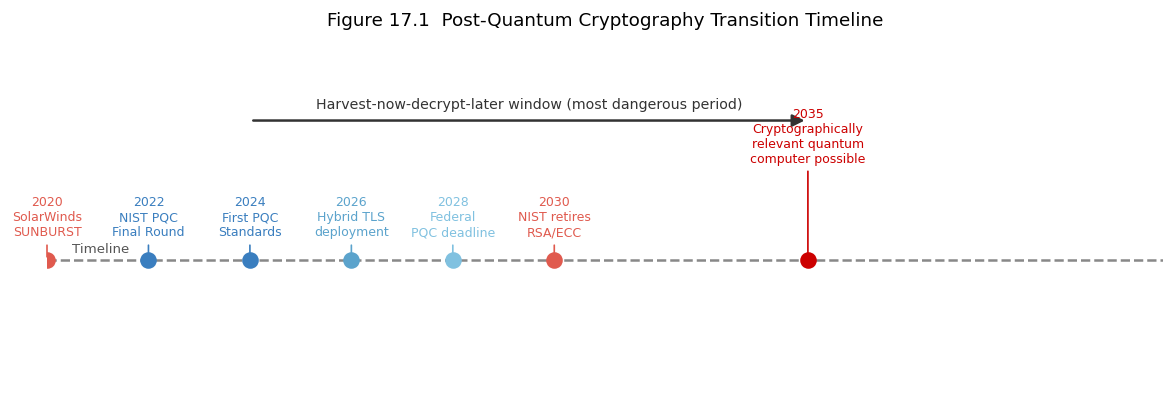

Figure 17.1 rendered.


In [1]:
# Chapter 17 -- Quantum threat timeline and PQC algorithm comparison

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from io import BytesIO
from IPython.display import display, Image

# ── PQC algorithm comparison table ───────────────────────────────────────────
print("=== NIST PQC Standardised Algorithms (2024) ===\n")

algorithms = [
    dict(name="ML-KEM (Kyber)",       use="Key Encapsulation",
         basis="Module Lattice",      pub_size="800-1568 B", perf="Fast"),
    dict(name="ML-DSA (Dilithium)",   use="Digital Signature",
         basis="Module Lattice",      pub_size="1312-2592 B",perf="Fast"),
    dict(name="SLH-DSA (SPHINCS+)",   use="Digital Signature",
         basis="Hash functions",      pub_size="32-64 B",    perf="Slower"),
    dict(name="FN-DSA (FALCON)",      use="Digital Signature",
         basis="NTRU Lattice",        pub_size="897-1793 B", perf="Fast"),
    dict(name="RSA-2048 (classical)", use="Key Exchange/Sig",
         basis="Integer factoring",   pub_size="256 B",      perf="Moderate"),
    dict(name="ECDSA P-256 (classical)",use="Digital Signature",
         basis="Elliptic curve DLP",  pub_size="64 B",       perf="Fast"),
]

print(f"  {'Algorithm':<25} {'Use':<22} {'Hard Problem':<22} {'Pub Key':<14} {'Speed'}")
print("  " + "-"*95)
for a in algorithms:
    quantum = "QUANTUM SAFE" if "classical" not in a["name"] else "VULNERABLE TO SHOR"
    print(f"  {a['name']:<25} {a['use']:<22} {a['basis']:<22} {a['pub_size']:<14} {a['perf']}"
          + f"   [{quantum}]")

# ── Quantum threat timeline visualisation ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off"); ax.set_xlim(2020, 2042); ax.set_ylim(-1, 3.5)

events = [
    (2020, 0.3, "SolarWinds\nSUNBURST", "#e05a4e"),
    (2022, 0.3, "NIST PQC\nFinal Round", "#3a7ebf"),
    (2024, 0.3, "First PQC\nStandards", "#3a7ebf"),
    (2026, 0.3, "Hybrid TLS\ndeployment", "#5ba3cc"),
    (2028, 0.3, "Federal\nPQC deadline", "#80c1e0"),
    (2030, 0.3, "NIST retires\nRSA/ECC", "#e05a4e"),
    (2035, 1.2, "Cryptographically\nrelevant quantum\ncomputer possible", "#c00"),
]

ax.axhline(0.8, xmin=0, xmax=1, color="#888", lw=1.5, ls="--")
ax.text(2020.5, 0.9, "Timeline", fontsize=8, color="#555")

for year, y_off, label, color in events:
    ax.scatter([year], [0.8], color=color, s=80, zorder=5)
    ax.annotate(f"{year}\n{label}", xy=(year, 0.8),
                xytext=(year, 0.8 + y_off),
                ha="center", fontsize=7.5,
                arrowprops=dict(arrowstyle="-", color=color, lw=1),
                color=color)

ax.add_patch(mpatches.FancyArrowPatch((2024, 2.5), (2035, 2.5),
             arrowstyle="-|>", color="#333", lw=1.5, mutation_scale=15))
ax.text(2029.5, 2.65, "Harvest-now-decrypt-later window (most dangerous period)",
        ha="center", fontsize=8.5, color="#333")

ax.set_title("Figure 17.1  Post-Quantum Cryptography Transition Timeline", fontsize=11, pad=8)
ax.set_xlabel("Year", fontsize=9)
ax.set_xticks(range(2020, 2042, 2))

_buf = BytesIO()
plt.savefig(_buf, format="png", dpi=120, bbox_inches="tight")
plt.close(); _buf.seek(0)
display(Image(data=_buf.read()))
print("Figure 17.1 rendered.")


## Review Questions (MCQ)

**Q1.** Shor's algorithm threatens RSA and ECC by:
A. Brute-forcing the key space  B. Efficiently solving integer factorisation and discrete logarithm on a quantum computer  C. Exploiting TLS implementation bugs  D. Requiring the private key to be transmitted

**Q2.** The first NIST PQC standard for key encapsulation is:
A. FALCON  B. SPHINCS+  C. ML-KEM (Kyber)  D. ML-DSA (Dilithium)

**Q3.** "Harvest now, decrypt later" describes:
A. Storing data until quantum computers can break current encryption  B. Collecting credentials for password spraying  C. Archiving logs for forensic use  D. Caching TLS sessions

**Q4.** The SolarWinds attack is classified as a supply chain attack because:
A. It targeted the solar energy sector  B. Malicious code was injected into a trusted software update distributed to thousands of organisations  C. It used a zero-day in Windows  D. It targeted cloud infrastructure

**Q5.** An SBOM primarily helps an organisation:
A. Audit IAM permissions  B. Rapidly identify which products contain a newly disclosed vulnerable component  C. Generate YARA rules  D. Perform threat modelling

**Q6.** In the cloud shared responsibility model, the customer is always responsible for:
A. Physical server security  B. Hypervisor patches  C. Their data, identity management, and application security  D. Network hardware failures

**Q7.** The Mirai botnet primarily compromised:
A. Windows servers  B. IoT devices with default credentials  C. Cloud VMs  D. SCADA systems

**Q8.** LLMs improve spear phishing effectiveness primarily by:
A. Breaking TLS encryption  B. Generating personalised, grammatically correct phishing content at scale  C. Automating network scanning  D. Cracking passwords

**Q9.** Google Project Zero's 90-day disclosure policy is designed to:
A. Give attackers time to develop exploits  B. Allow indefinite vendor delay  C. Create patch pressure while giving vendors a reasonable remediation window  D. Prevent all public disclosure

**Q10.** Hybrid classical/PQC key exchange (e.g., ECDHE + ML-KEM) is deployed to:
A. Improve TLS performance  B. Provide protection during migration even if one algorithm is later broken  C. Eliminate certificate authorities  D. Reduce key sizes

*Answers: Q1 B, Q2 C, Q3 A, Q4 B, Q5 B, Q6 C, Q7 B, Q8 B, Q9 C, Q10 B.*

## Lab Assignment

**Part A -- Cryptographic inventory**: Audit a web service you control (your own server, a lab VM, or a cloud instance). Use `nmap --script ssl-enum-ciphers -p 443` to list the TLS cipher suites offered. Identify: which key exchange algorithm is used, whether it is forward-secret, and whether it uses a quantum-vulnerable algorithm.

**Part B -- PQC algorithm comparison**: Using the NIST PQC documentation, compare ML-KEM-768 and ML-KEM-1024 on four dimensions: public key size, ciphertext size, security level (NIST level), and performance. Explain the trade-off between ML-KEM-768 and ML-KEM-1024 for TLS deployment.

**Part C -- Supply chain risk assessment**: For a fictional organisation that uses 20 Python packages in a web application, describe the process for generating an SBOM using `pip-audit` or `cyclonedx-py`. Explain how you would use the SBOM to respond if a critical CVE were disclosed in one of those packages.

**Part D -- AI threat model**: Draft a one-page threat model for AI-enabled attacks on a 500-person financial services firm. Include: which roles are most vulnerable to AI-enhanced phishing/vishing, which defences are most effective (phishing-resistant MFA, deepfake detection, voice authentication review), and one emerging AI threat the firm should monitor.

## References

```{bibliography}
:filter: docname in docnames
```

**Related work by the author (see Appendix E and F):**

- Trivedi, D. et al. *SigML / SigML++* (supervised log anomaly with homomorphic encryption) and *SplitML* (federated split-learning); *Evaluating Classification Algorithms*; *Hash Function Generation by Neural Network*; companion repo *LSTM-Demo* (bidirectional LSTM in TensorFlow).
- Hahn, F., et al. Searchable/homomorphic encryption, function secret sharing, privacy-preserving federated learning (UTwente). https://research.utwente.nl/en/persons/florian-werner-hahn/
- Luby, M. "LT Codes." FOCS, 2002 (soliton and robust soliton degree distributions).
- McMahan, B., et al. "Communication-Efficient Learning of Deep Networks from Decentralized Data" (federated learning), 2017. Gupta and Raskar, "Distributed learning of deep neural network over multiple agents" (split learning), 2018.
1. Trivedi, D. et al. (2023). SigML: Supervised Log Anomaly Detection with Fully Homomorphic Encryption. CSCML 2023. (see Appendix E)

2. Trivedi, D. et al. (2023). SigML++: Improved Polynomial Approximation for Encrypted Log Anomaly Detection. Cryptography (MDPI), 7(4), 52. (see Appendix E)

3. Trivedi, D. et al. (2026). SplitML: Secure Federated Split Learning with FHE and Differential Privacy. Electronics (MDPI), 15(2), 267. (see Appendix E)



```{index} Post-quantum cryptography, Shor's algorithm, NIST PQC, Supply chain attack, AI/ML in security, LLM, Deepfake, Zero-day, Exploit broker, Shared responsibility model, IoT, SBOM
```
